<a href="https://colab.research.google.com/github/LakshmiSingh789/CAPSTONE-PROJECT-IIT-BHU-/blob/main/CAPSTONE_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning for Iron–Carbon Phase Diagram Analysis

# Import Libraries and Load Dataset

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load the dataset & display

In [65]:
url = "https://raw.githubusercontent.com/Lakshmisingh789/CAPSTONE-PROJECT-IIT-BHU-/main/NIMS_Fatigue.csv"

df = pd.read_csv(url)

In [66]:
df.head()

,NT,QT,TT,C,Si,Mn,P,S,Ni,Cr,Cu,Mo,RR,dA,dB,dC,Fatigue,Tensile,Fracture,Hardness
0,865,865,550,0.40,0.968,0.64,0.020,0.129,0.039,0.01,0.156,0.0,1740,0.07,0.03,0.00,426,1471.66,2842,260
1,865,865,550,0.35,0.210,0.77,0.021,0.022,0.010,0.01,0.020,0.0,825,0.05,0.03,0.00,397,736.00,1482,235
2,865,865,550,0.35,0.300,0.74,0.017,0.024,0.010,0.10,0.010,0.0,1270,0.07,0.02,0.00,419,736.00,1492,249
3,865,865,550,0.34,0.260,0.74,0.012,0.015,0.010,0.02,0.010,0.0,1740,0.08,0.00,0.00,401,690.00,1484,239
4,865,865,550,0.36,0.260,0.70,0.009,0.023,0.080,0.12,0.090,0.0,610,0.07,0.00,0.03,394,790.00,1440,261


In [67]:
df.tail()

,NT,QT,TT,C,Si,Mn,P,S,Ni,Cr,Cu,Mo,RR,dA,dB,dC,Fatigue,Tensile,Fracture,Hardness
356,870,845,680,0.47,0.19,0.76,0.013,0.013,1.67,0.71,0.06,0.0,640,0.02,0.0,0.00,476,878.0,1653,281
357,870,845,680,0.44,0.25,0.74,0.010,0.009,1.74,0.79,0.09,0.0,820,0.02,0.0,0.02,482,895.0,1625,287
358,870,845,680,0.45,0.16,0.79,0.009,0.016,1.65,0.73,0.05,0.0,640,0.01,0.0,0.00,477,860.0,1680,281
359,870,845,680,0.48,0.20,0.70,0.010,0.016,1.66,0.73,0.11,0.0,640,0.03,0.0,0.00,491,881.0,1668,286
360,870,845,680,0.49,0.29,0.69,0.014,0.011,1.80,0.77,0.07,0.0,820,0.06,0.0,0.01,479,909.0,1633,290


In [68]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 361
Columns : 20


In [69]:
print(df.columns)

Index(['NT', 'QT', 'TT', 'C', 'Si', 'Mn', 'P', 'S', 'Ni', 'Cr', 'Cu', 'Mo',
       'RR', 'dA', 'dB', 'dC', 'Fatigue', 'Tensile', 'Fracture', 'Hardness'],
      dtype='object')


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 361 entries, 0 to 360
Data columns (total 20 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   NT        361 non-null    int64  
 1   QT        361 non-null    int64  
 2   TT        361 non-null    int64  
 3   C         361 non-null    float64
 4   Si        361 non-null    float64
 5   Mn        361 non-null    float64
 6   P         361 non-null    float64
 7   S         361 non-null    float64
 8   Ni        361 non-null    float64
 9   Cr        361 non-null    float64
 10  Cu        361 non-null    float64
 11  Mo        361 non-null    float64
 12  RR        361 non-null    int64  
 13  dA        361 non-null    float64
 14  dB        361 non-null    float64
 15  dC        361 non-null    float64
 16  Fatigue   361 non-null    int64  
 17  Tensile   361 non-null    float64
 18  Fracture  361 non-null    int64  
 19  Hardness  361 non-null    int64  
dtypes: float64(13), int64(7)
memory 

In [71]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
NT,361.0,865.581717,17.346777,825.000,865.000,870.000,870.000,900.000
QT,361.0,848.296399,9.885074,825.000,845.000,845.000,855.000,865.000
TT,361.0,604.847645,42.426951,550.000,550.000,600.000,650.000,680.000
C,361.0,0.407313,0.061248,0.280,0.370,0.400,0.430,0.570
Si,361.0,0.260216,0.050496,0.160,0.240,0.260,0.280,0.968
Mn,361.0,0.848006,0.294040,0.370,0.710,0.750,0.800,1.600
P,361.0,0.015870,0.004846,0.007,0.012,0.016,0.019,0.031
S,361.0,0.014767,0.008546,0.003,0.009,0.015,0.019,0.129
Ni,361.0,0.546756,0.898027,0.010,0.020,0.050,0.240,2.780
Cr,361.0,0.554571,0.419436,0.010,0.100,0.720,0.980,1.120


# Data Pre-processing

In [72]:
print("Missing Values")

df.isnull().sum()

Missing Values


,0
NT,0
QT,0
TT,0
C,0
Si,0
Mn,0
P,0
S,0
Ni,0
Cr,0


In [73]:
print("Duplicate Rows :",df.duplicated().sum())

Duplicate Rows : 0


In [74]:
df=df.drop_duplicates()

In [75]:
print(df.shape)

(361, 20)


In [76]:
df.dtypes

,0
NT,int64
QT,int64
TT,int64
C,float64
Si,float64
Mn,float64
P,float64
S,float64
Ni,float64
Cr,float64


In [77]:
corr=df.corr(numeric_only=True)

corr

,NT,QT,TT,C,Si,Mn,P,S,Ni,Cr,Cu,Mo,RR,dA,dB,dC,Fatigue,Tensile,Fracture,Hardness
NT,1.000000,0.506357,0.030126,-0.807965,0.089759,-0.007451,-0.258317,-0.359985,0.569492,0.531186,0.194086,0.187233,-0.167218,-0.608143,-0.170382,0.107948,0.310352,0.267689,0.431653,0.242492
QT,0.506357,1.000000,-0.044831,-0.714362,0.100741,-0.103525,-0.055959,0.011078,-0.181479,0.308895,0.107681,0.227666,-0.022814,-0.096941,0.194752,-0.005454,-0.039879,0.005772,0.141692,-0.013309
TT,0.030126,-0.044831,1.000000,0.021916,-0.056891,-0.044780,-0.059203,-0.079164,0.159295,0.064358,0.022728,0.105322,-0.014122,-0.024489,-0.036832,-0.026655,-0.407203,-0.455975,-0.258345,-0.471951
C,-0.807965,-0.714362,0.021916,1.000000,-0.070298,0.111865,0.072281,0.201479,-0.298901,-0.355563,-0.117589,-0.229723,0.096153,0.335961,-0.085327,-0.076659,-0.044620,-0.010250,-0.202047,0.003561
Si,0.089759,0.100741,-0.056891,-0.070298,1.000000,-0.102545,0.033624,0.420796,0.034822,0.104793,0.216875,0.071121,0.067286,0.035820,0.041411,0.009803,0.091734,0.291424,0.417816,0.092293
Mn,-0.007451,-0.103525,-0.044780,0.111865,-0.102545,1.000000,0.005665,-0.022637,-0.379564,-0.415529,-0.093881,-0.250662,-0.017836,-0.191576,-0.105776,-0.078939,-0.268664,-0.206984,-0.234099,-0.193274
P,-0.258317,-0.055959,-0.059203,0.072281,0.033624,0.005665,1.000000,0.207729,-0.251611,-0.153199,-0.273623,0.018016,0.219553,0.375643,0.091586,-0.228403,-0.077040,-0.087072,-0.104507,-0.096702
S,-0.359985,0.011078,-0.079164,0.201479,0.420796,-0.022637,0.207729,1.000000,-0.294934,-0.350833,-0.006647,-0.111744,0.121340,0.384975,0.304881,-0.097424,-0.258765,-0.065432,0.053936,-0.231551
Ni,0.569492,-0.181479,0.159295,-0.298901,0.034822,-0.379564,-0.251611,-0.294934,1.000000,0.316330,0.099135,0.114326,-0.132984,-0.345978,-0.148851,0.086246,0.349284,0.250572,0.334966,0.218475
Cr,0.531186,0.308895,0.064358,-0.355563,0.104793,-0.415529,-0.153199,-0.350833,0.316330,1.000000,0.344499,0.666718,-0.133007,-0.384751,-0.319316,0.072322,0.726889,0.680470,0.726629,0.703094


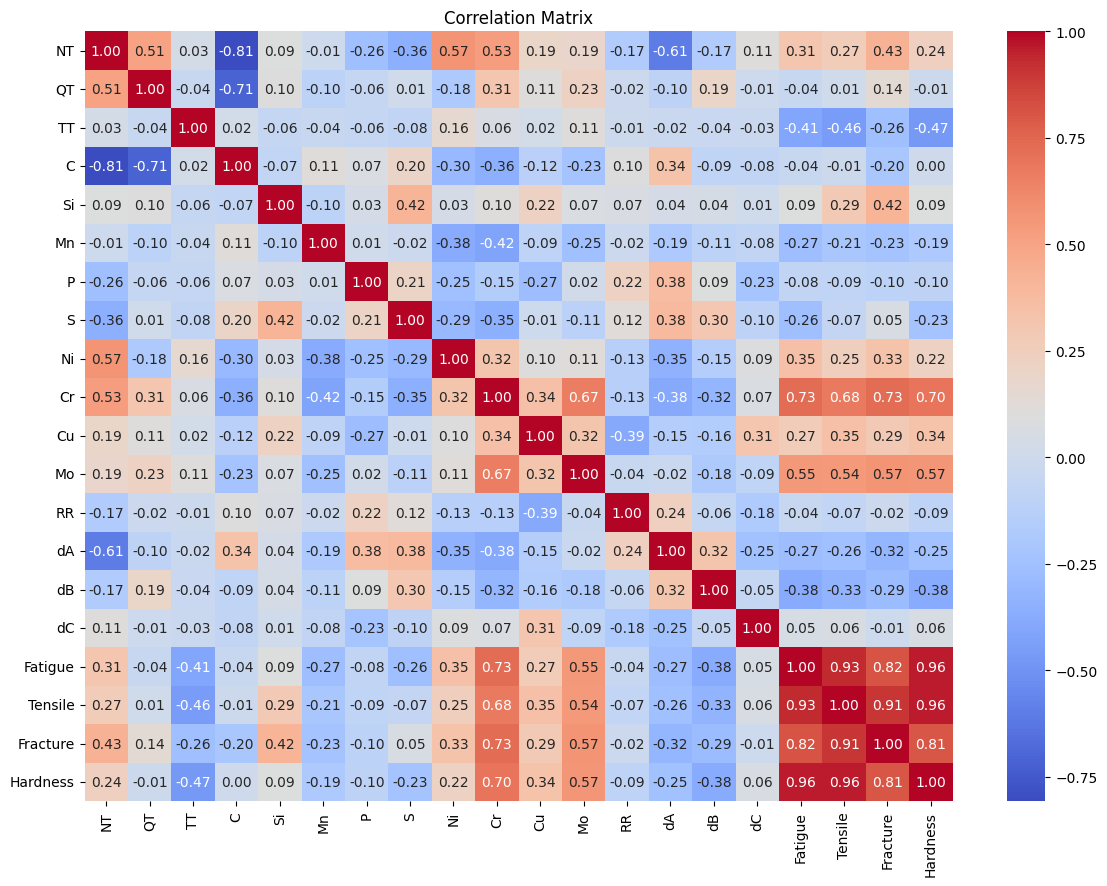

In [78]:
plt.figure(figsize=(14,10))

sns.heatmap(corr,
            cmap='coolwarm',
            annot=True,
            fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

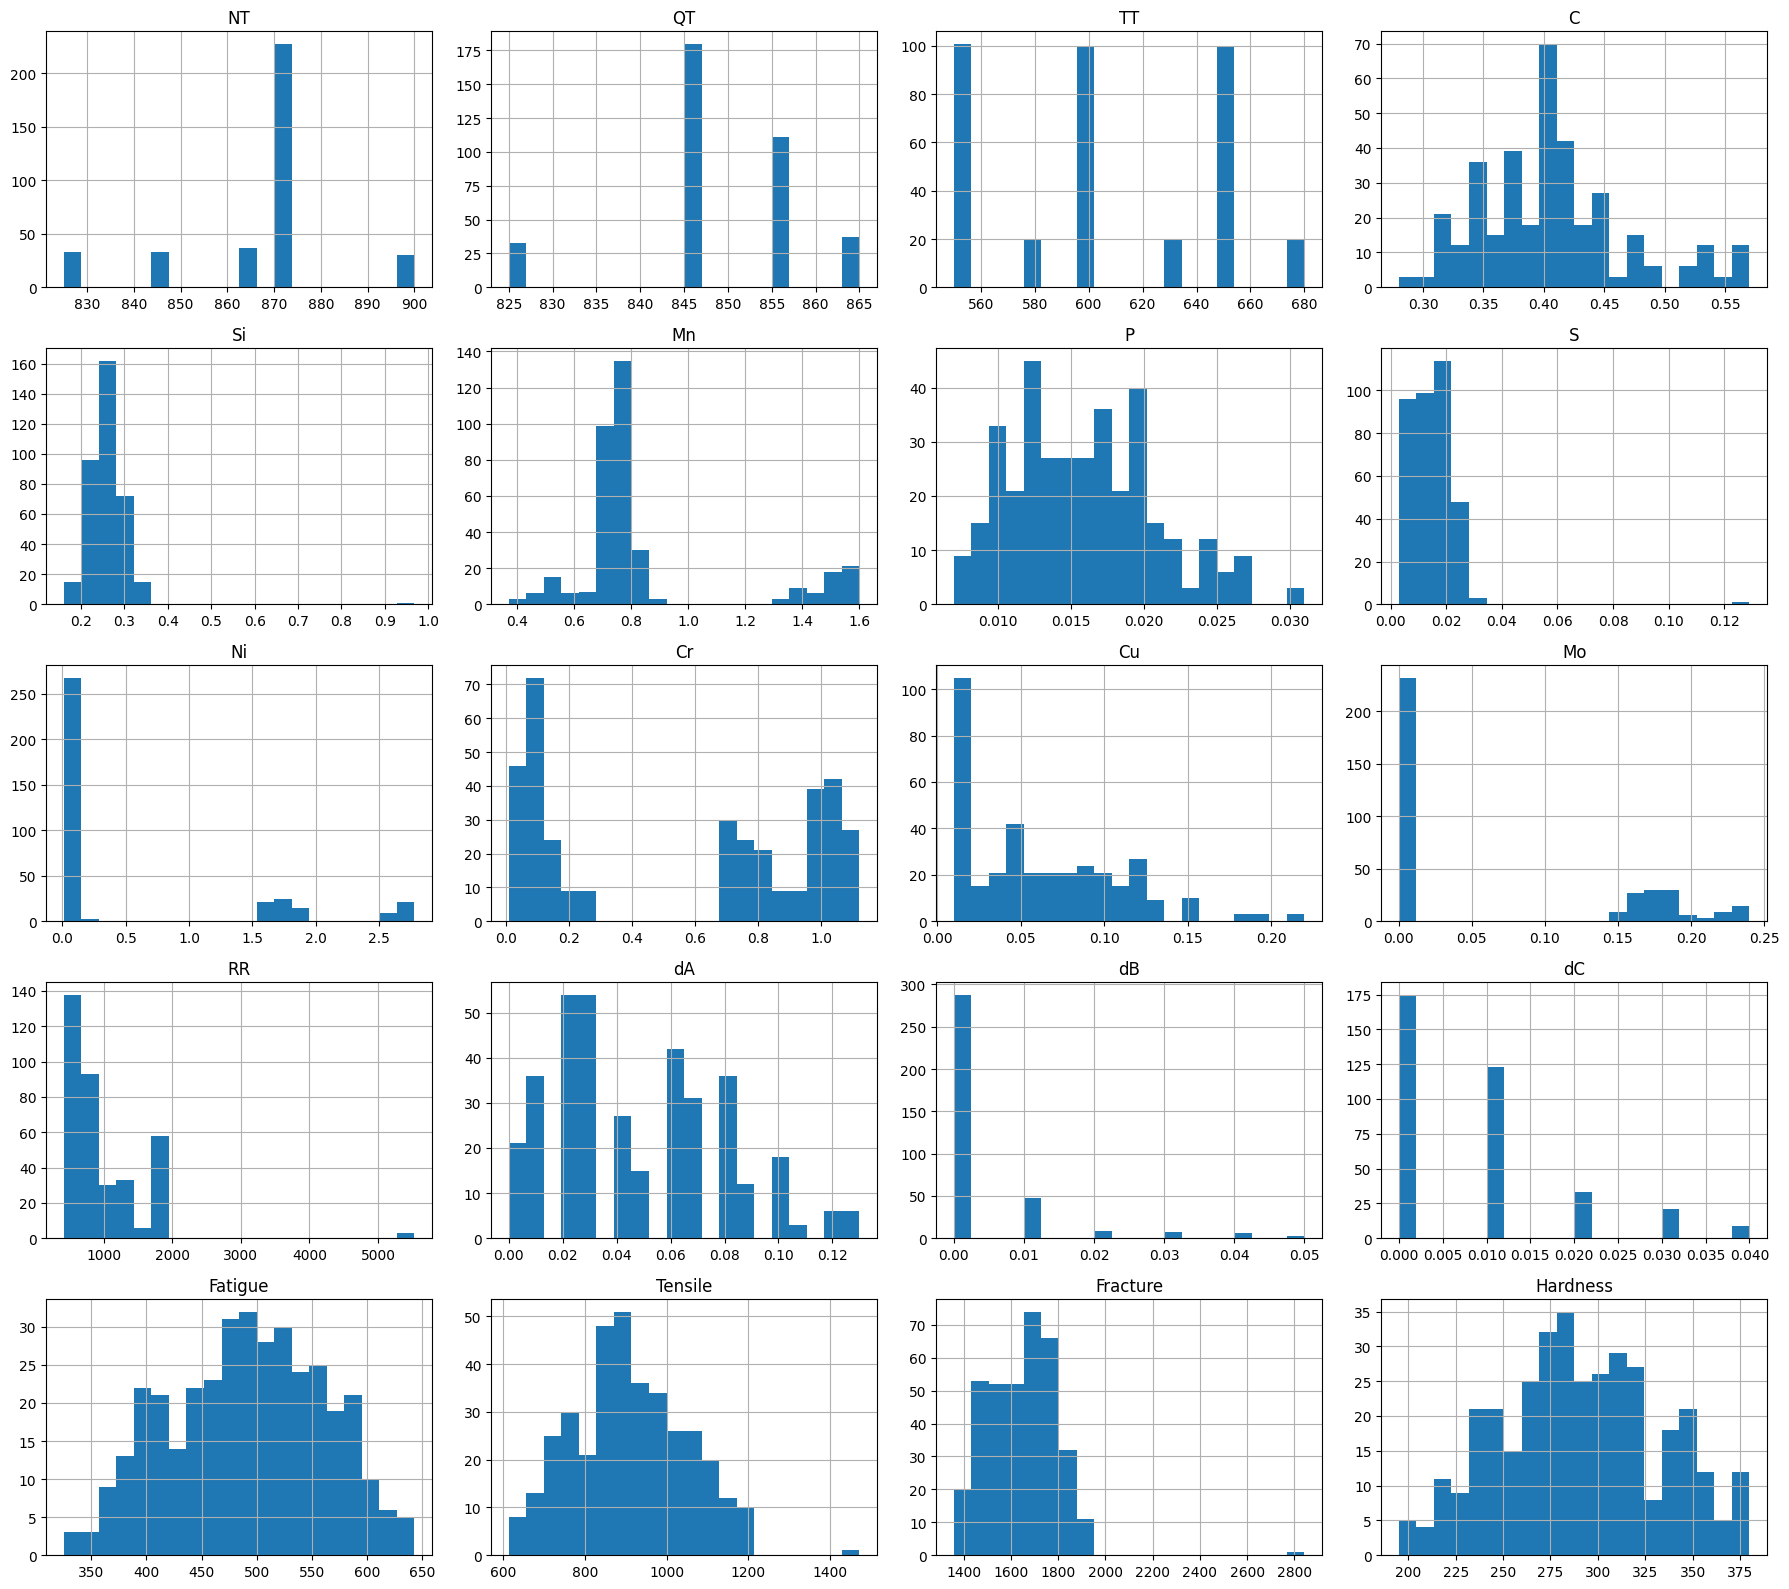

In [79]:
df.hist(figsize=(18,16),
        bins=20)

plt.tight_layout()

plt.show()

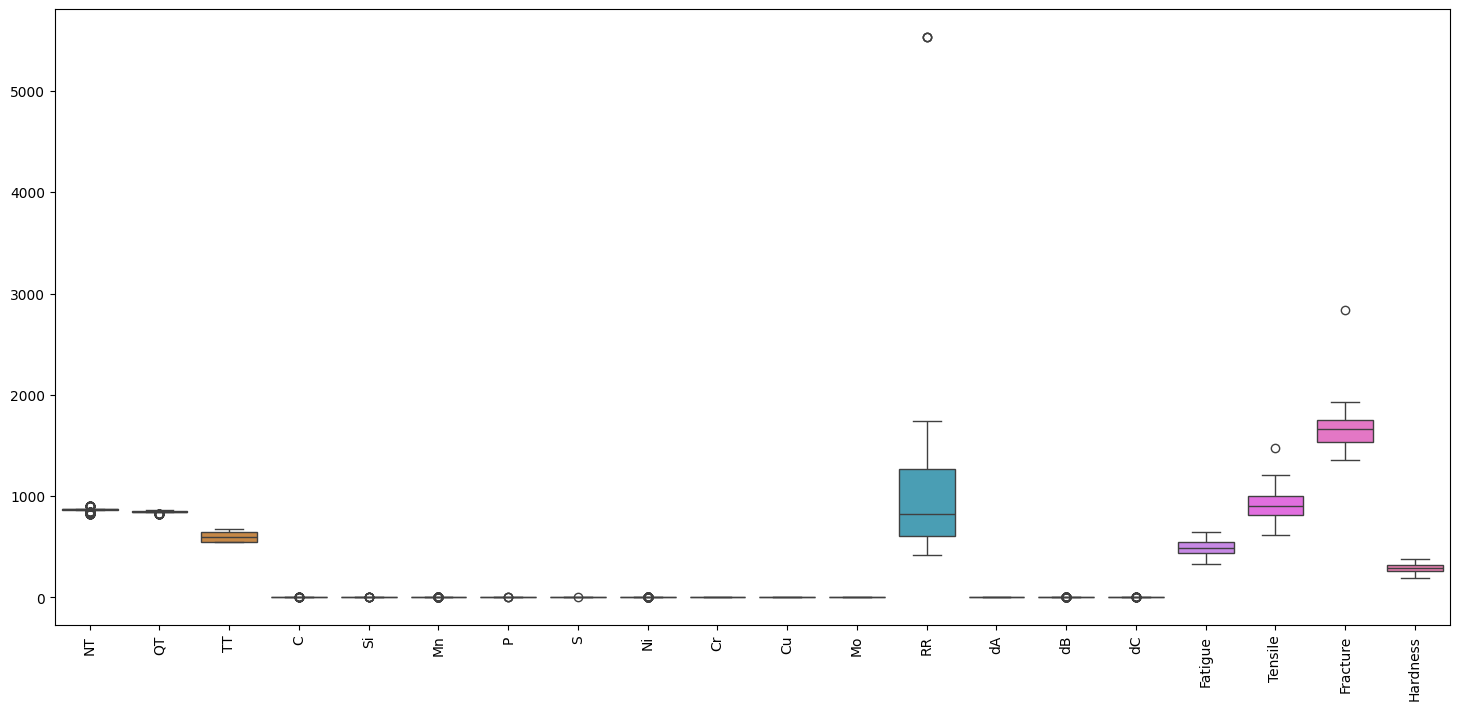

In [80]:
plt.figure(figsize=(18,8))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.show()

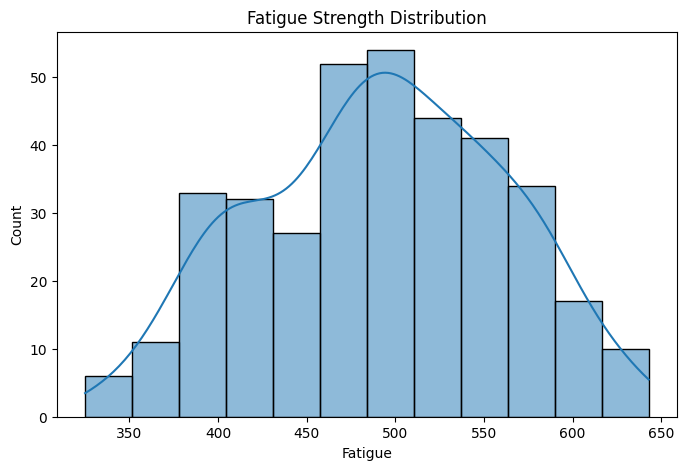

In [81]:
plt.figure(figsize=(8,5))

sns.histplot(df["Fatigue"],
             kde=True)

plt.title("Fatigue Strength Distribution")

plt.show()

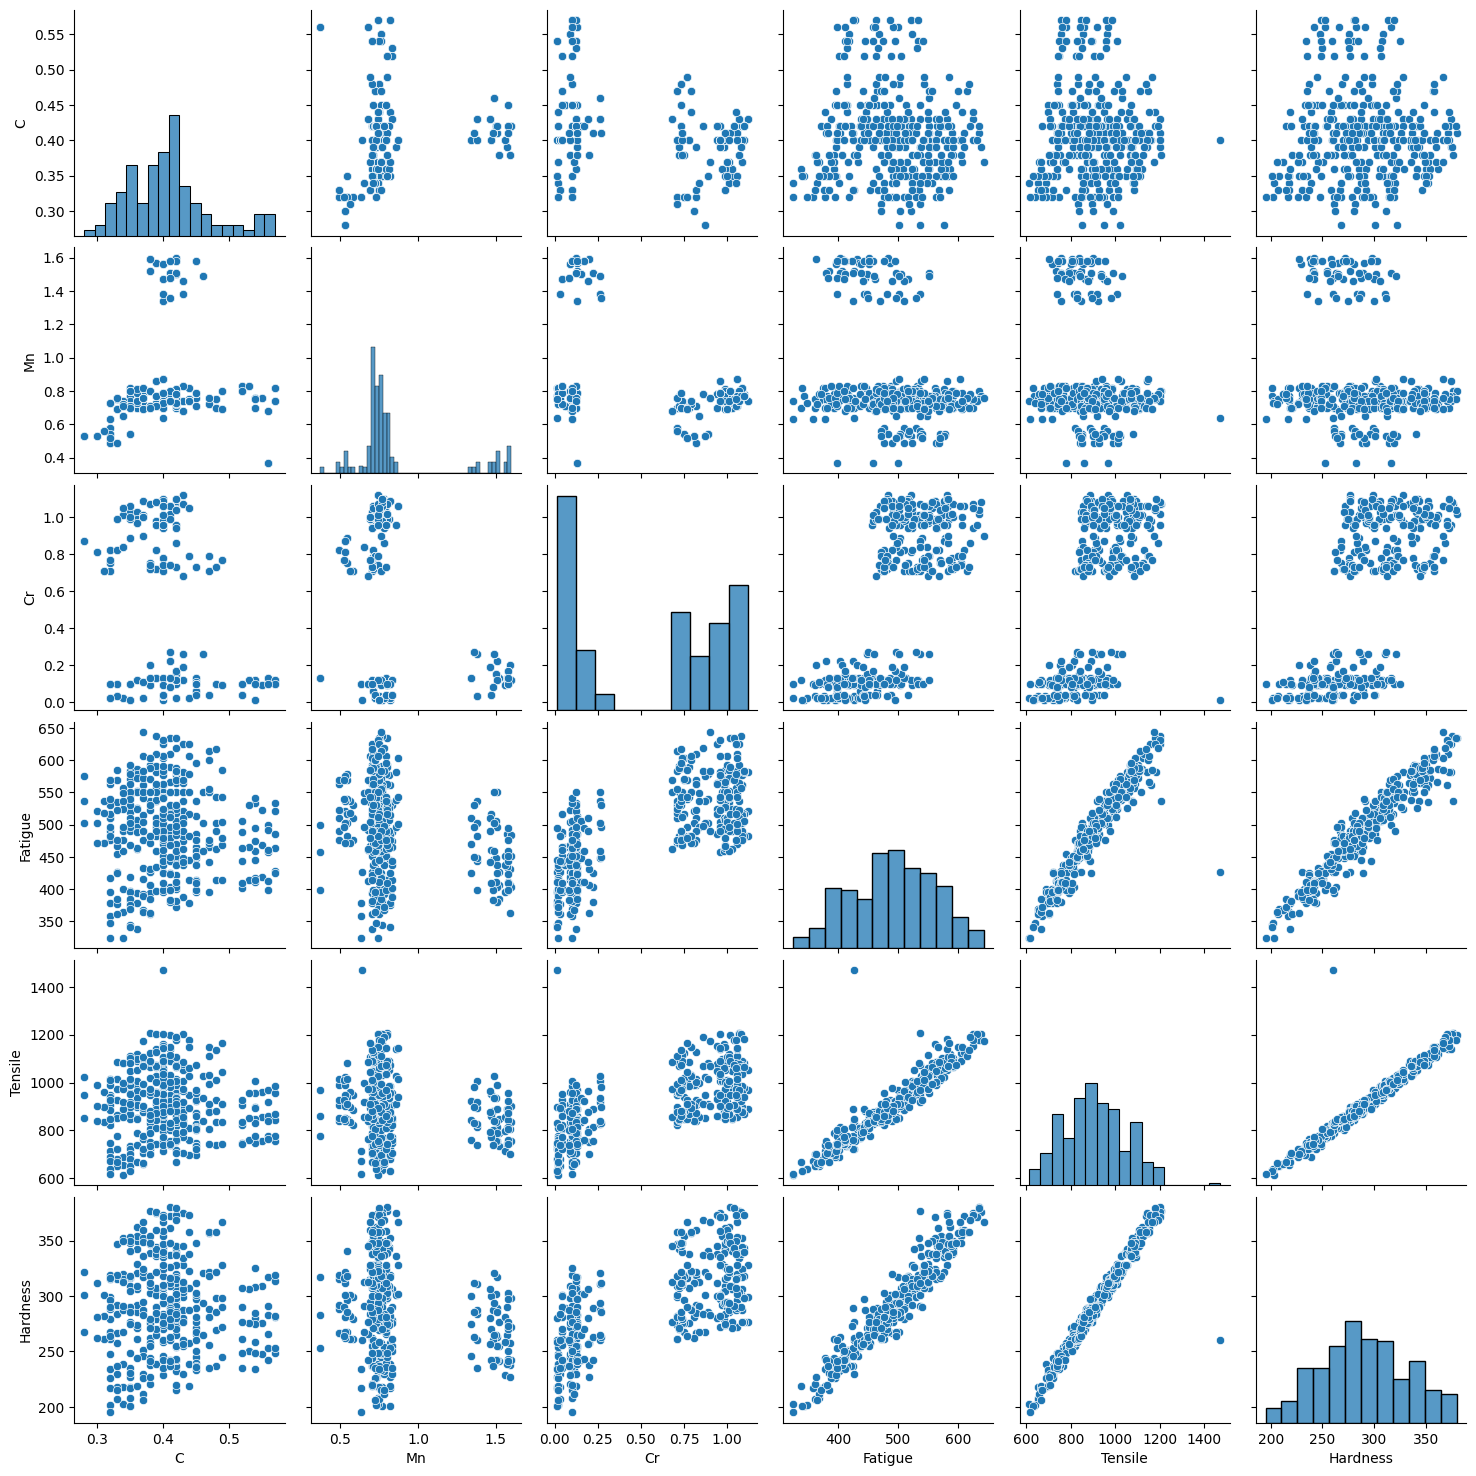

In [82]:
sns.pairplot(df[["C","Mn","Cr","Fatigue","Tensile","Hardness"]])

plt.show()

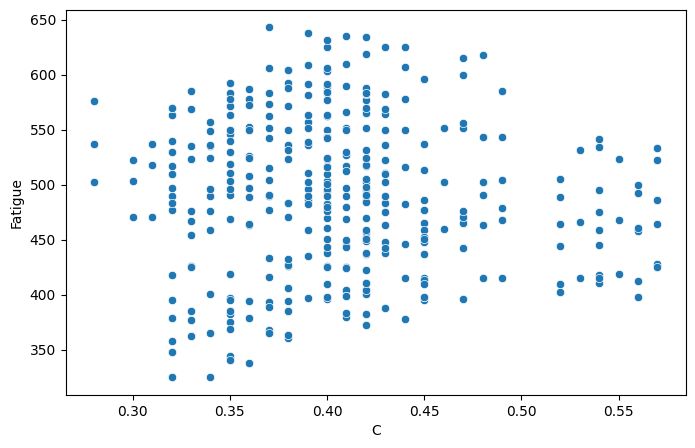

In [83]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df,
                x="C",
                y="Fatigue")

plt.show()

In [84]:
corr_target=df.corr(numeric_only=True)["Fatigue"].sort_values(ascending=False)

print(corr_target)

Fatigue     1.000000
Hardness    0.960588
Tensile     0.934879
Fracture    0.815940
Cr          0.726889
Mo          0.551069
Ni          0.349284
NT          0.310352
Cu          0.268982
Si          0.091734
dC          0.047713
RR         -0.039244
QT         -0.039879
C          -0.044620
P          -0.077040
S          -0.258765
Mn         -0.268664
dA         -0.273593
dB         -0.382658
TT         -0.407203
Name: Fatigue, dtype: float64


In [85]:
X=df.drop("Fatigue",axis=1)

y=df["Fatigue"]

print(X.shape)

print(y.shape)

(361, 19)
(361,)


In [86]:
# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [87]:
X_train,X_test,y_train,y_test=train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

In [88]:
#feature Scaling
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)

X_test=scaler.transform(X_test)

In [89]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(288, 19)
(73, 19)
(288,)
(73,)


In [90]:
# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [91]:
# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [92]:
# XGBoost
from xgboost import XGBRegressor

In [93]:
# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Machine Learning Models

Step 1: Linear Regression

In [94]:
# Create Model
lr = LinearRegression()

# Train Model
lr.fit(X_train, y_train)

# Prediction
lr_pred = lr.predict(X_test)

In [95]:
# Evaluation
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_pred)

In [96]:
print("MAE :", lr_mae)
print("MSE :", lr_mse)
print("RMSE :", lr_rmse)
print("R² Score :", lr_r2)

MAE : 11.74364097529544
MSE : 250.28032745960445
RMSE : 15.820250549836574
R² Score : 0.9526806800960053


Step 2: Actual vs Predicted (Linear Regression)

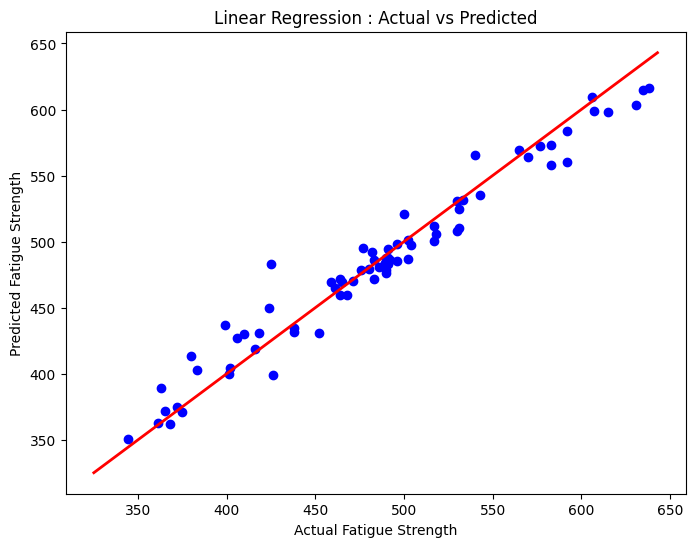

In [97]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, lr_pred, color='blue')

plt.plot([y.min(), y.max()],
         [y.min(), y.max()],
         color='red',
         linewidth=2)

plt.xlabel("Actual Fatigue Strength")
plt.ylabel("Predicted Fatigue Strength")
plt.title("Linear Regression : Actual vs Predicted")

plt.show()

Step 3: Residual Plot

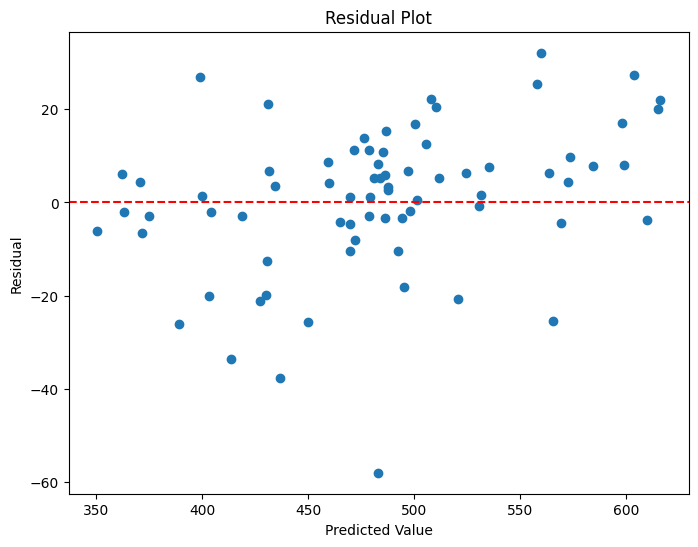

In [98]:
residual = y_test - lr_pred

plt.figure(figsize=(8,6))

plt.scatter(lr_pred, residual)

plt.axhline(y=0,
            color='red',
            linestyle='--')

plt.xlabel("Predicted Value")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

Step 4: Decision Tree Regressor

In [99]:
dt = DecisionTreeRegressor(
        max_depth=8,
        random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)

print("MAE :", dt_mae)
print("MSE :", dt_mse)
print("RMSE :", dt_rmse)
print("R² :", dt_r2)

MAE : 18.457077625570776
MSE : 563.6695497468394
RMSE : 23.741725921820414
R² : 0.8934296593929608


Step 5: Random Forest Regressor

In [100]:
rf = RandomForestRegressor(

            n_estimators=300,

            max_depth=10,

            random_state=42,

            n_jobs=-1

)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE :", rf_rmse)
print("R² :", rf_r2)

MAE : 12.935963328664775
MSE : 319.082595839586
RMSE : 17.862883189440222
R² : 0.9396725600386335


Step 6: Actual vs Predicted (Random Forest)

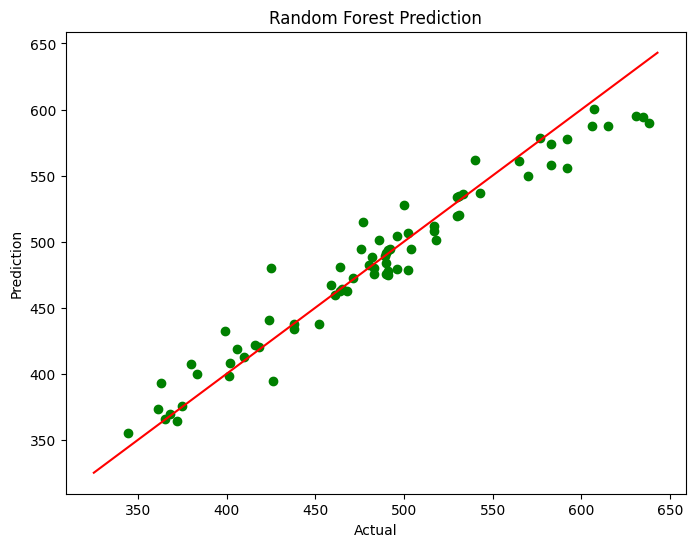

In [101]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,
            rf_pred,
            color='green')

plt.plot([y.min(),y.max()],
         [y.min(),y.max()],
         color='red')

plt.xlabel("Actual")

plt.ylabel("Prediction")

plt.title("Random Forest Prediction")

plt.show()

Step 7: Residual Plot (Random Forest)

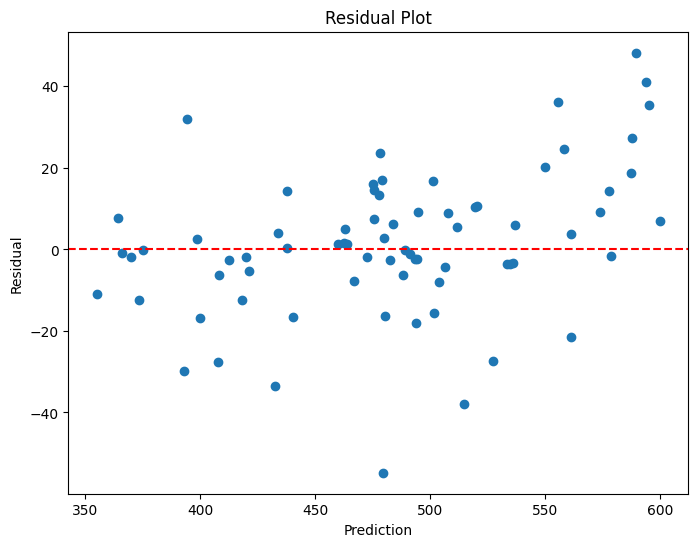

In [102]:
residual = y_test-rf_pred

plt.figure(figsize=(8,6))

plt.scatter(rf_pred,
            residual)

plt.axhline(0,
            color='red',
            linestyle='--')

plt.xlabel("Prediction")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

Step 8: Feature Importance

In [103]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(

        by="Importance",

        ascending=False

)

importance

,Feature,Importance
16,Tensile,0.599160
18,Hardness,0.345148
17,Fracture,0.021316
9,Cr,0.003878
8,Ni,0.003814
5,Mn,0.003573
10,Cu,0.003514
3,C,0.003400
7,S,0.002931
6,P,0.002745


Step 9: Plot Feature Importance

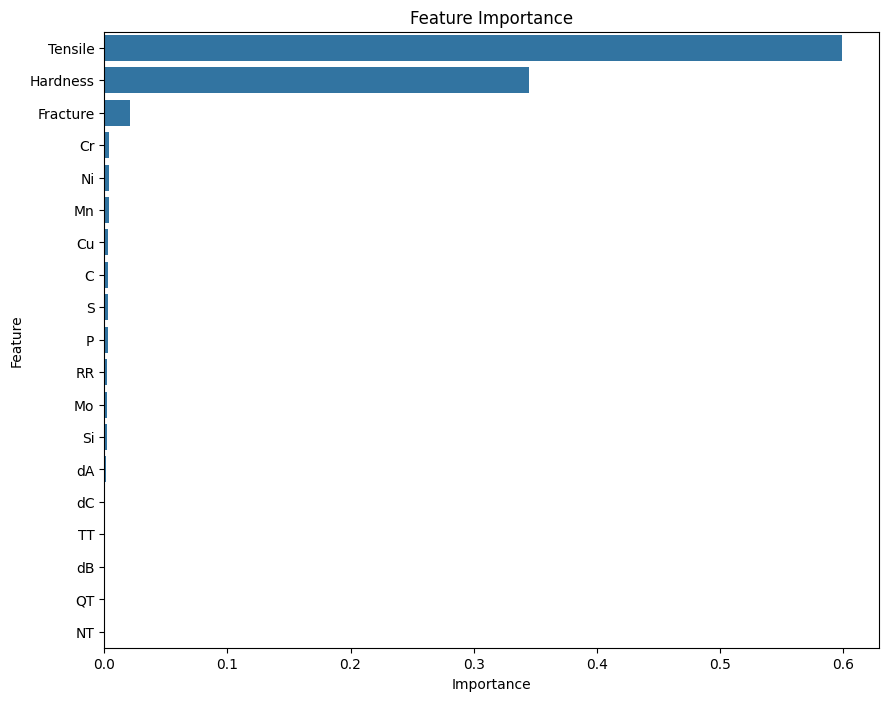

In [104]:
plt.figure(figsize=(10,8))

sns.barplot(

        data=importance,

        x="Importance",

        y="Feature"

)

plt.title("Feature Importance")

plt.show()

Step 10: Top 10 Important Features

In [105]:
top10 = importance.head(10)

print(top10)

     Feature  Importance
16   Tensile    0.599160
18  Hardness    0.345148
17  Fracture    0.021316
9         Cr    0.003878
8         Ni    0.003814
5         Mn    0.003573
10        Cu    0.003514
3          C    0.003400
7          S    0.002931
6          P    0.002745


Step 11: Compare All Models

In [106]:
result = pd.DataFrame({

"Model":["Linear Regression",

         "Decision Tree",

         "Random Forest"],

"MAE":[lr_mae,

       dt_mae,

       rf_mae],

"RMSE":[lr_rmse,

        dt_rmse,

        rf_rmse],

"R2":[lr_r2,

      dt_r2,

      rf_r2]

})

result

,Model,MAE,RMSE,R2
0,Linear Regression,11.743641,15.820251,0.952681
1,Decision Tree,18.457078,23.741726,0.893430
2,Random Forest,12.935963,17.862883,0.939673


Step 12: Find the Best Model

In [107]:
best = result.sort_values(

        by="R2",

        ascending=False

)

best

,Model,MAE,RMSE,R2
0,Linear Regression,11.743641,15.820251,0.952681
2,Random Forest,12.935963,17.862883,0.939673
1,Decision Tree,18.457078,23.741726,0.893430


Step 13: Save Results

In [108]:
result.to_csv("Model_Comparison.csv",

              index=False)

print("Results Saved Successfully")
print(best)

Results Saved Successfully
               Model        MAE       RMSE        R2
0  Linear Regression  11.743641  15.820251  0.952681
2      Random Forest  12.935963  17.862883  0.939673
1      Decision Tree  18.457078  23.741726  0.893430


# PART 3: Artificial Neural Network (ANN)

Step 1: Import TensorFlow

In [109]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

print(tf.__version__)

2.20.0


Step 2: Build ANN Model

In [110]:
# Create ANN Model

ann = Sequential()

# Input Layer
ann.add(Dense(128,
              activation='relu',
              input_shape=(X_train.shape[1],)))

ann.add(Dropout(0.2))

# Hidden Layer 1
ann.add(Dense(64,
              activation='relu'))

ann.add(Dropout(0.2))

# Hidden Layer 2
ann.add(Dense(32,
              activation='relu'))

# Output Layer
ann.add(Dense(1))

ann.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

Step 3: Compile Model

In [111]:
ann.compile(

    optimizer='adam',

    loss='mse',

    metrics=['mae']

)

Step 4: Early Stopping

In [112]:
early_stop = EarlyStopping(

        monitor='val_loss',

        patience=20,

        restore_best_weights=True

)

Step 5: Train ANN

In [113]:
history = ann.fit(

        X_train,

        y_train,

        validation_split=0.2,

        epochs=200,

        batch_size=16,

        callbacks=[early_stop],

        verbose=1

)

Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - loss: 246040.4375 - mae: 491.3127 - val_loss: 250625.1406 - val_mae: 495.8243
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 243854.9062 - mae: 489.0535 - val_loss: 247414.5625 - val_mae: 492.5695
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 239343.5469 - mae: 484.4204 - val_loss: 240291.8594 - val_mae: 485.2598
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 229334.8906 - mae: 473.9502 - val_loss: 224484.7188 - val_mae: 468.6446
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 208142.7969 - mae: 450.8886 - val_loss: 192737.0625 - val_mae: 433.5383
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 167826.2188 - mae: 403.0186 - val_loss: 138973.7969 - val_mae: 366.3409
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 106360.2734 - mae: 316.3764 - val_loss: 69407.6797 - val_mae: 251.7758
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 43430.4883 - mae: 186.1

Step 6: Plot Loss Curve

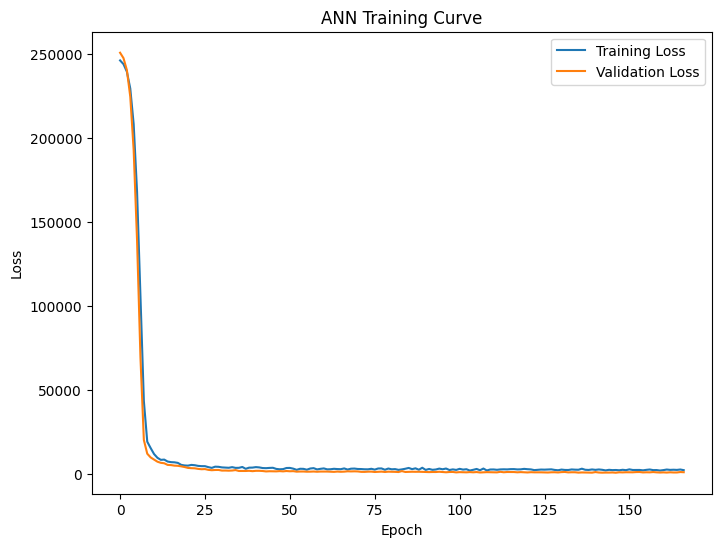

In [114]:
plt.figure(figsize=(8,6))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("ANN Training Curve")

plt.legend()

plt.show()

Step 7: Prediction & Evaluation

In [115]:
ann_pred = ann.predict(X_test)
ann_pred = ann_pred.flatten()


ann_mae = mean_absolute_error(

            y_test,

            ann_pred

)

ann_mse = mean_squared_error(

            y_test,

            ann_pred

)

ann_rmse = np.sqrt(ann_mse)

ann_r2 = r2_score(

            y_test,

            ann_pred

)

print("MAE :",ann_mae)

print("RMSE :",ann_rmse)

print("R2 :",ann_r2)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
MAE : 19.56003189086914
RMSE : 24.406224991984626
R2 : 0.8873806595802307


Step 8: Actual vs Prediction

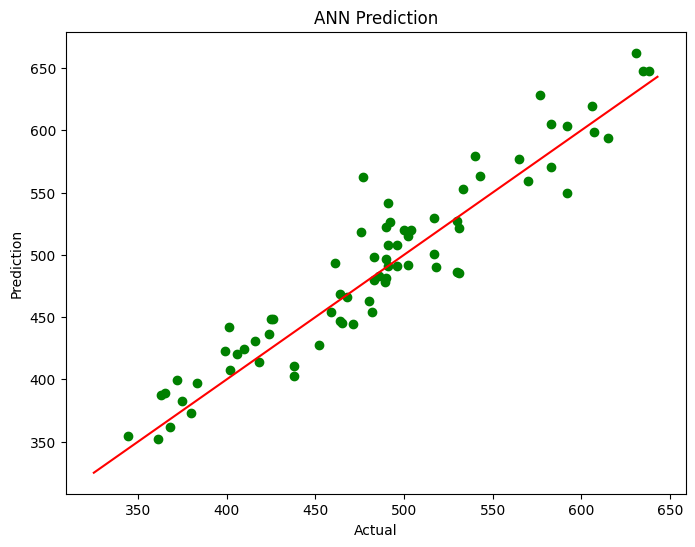

In [116]:
plt.figure(figsize=(8,6))

plt.scatter(

        y_test,

        ann_pred,

        color='green'

)

plt.plot(

    [y.min(),y.max()],

    [y.min(),y.max()],

    color='red'

)

plt.xlabel("Actual")

plt.ylabel("Prediction")

plt.title("ANN Prediction")

plt.show()

# PART 4 : XGBoost Regressor

Step 9: Train XGBoost

In [117]:
xgb = XGBRegressor(

        n_estimators=300,

        learning_rate=0.05,

        max_depth=6,

        subsample=0.8,

        colsample_bytree=0.8,

        random_state=42

)

xgb.fit(

        X_train,

        y_train

)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

Step 10: Prediction & Evaluation

In [118]:
xgb_pred = xgb.predict(

        X_test

)


xgb_mae = mean_absolute_error(

            y_test,

            xgb_pred

)

xgb_mse = mean_squared_error(

            y_test,

            xgb_pred

)

xgb_rmse = np.sqrt(xgb_mse)

xgb_r2 = r2_score(

            y_test,

            xgb_pred

)

print("MAE :",xgb_mae)

print("RMSE :",xgb_rmse)

print("R2 :",xgb_r2)

MAE : 12.736898422241211
RMSE : 17.26645660468993
R2 : 0.9436338543891907


Step 11: Actual vs Predicted

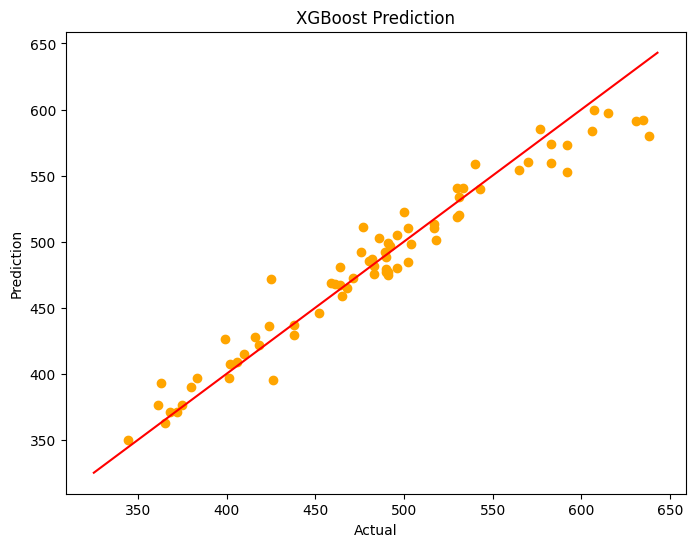

In [119]:
plt.figure(figsize=(8,6))

plt.scatter(

        y_test,

        xgb_pred,

        color='orange'

)

plt.plot(

    [y.min(),y.max()],

    [y.min(),y.max()],

    color='red'

)

plt.xlabel("Actual")

plt.ylabel("Prediction")

plt.title("XGBoost Prediction")

plt.show()

Step 13: Plot Importance

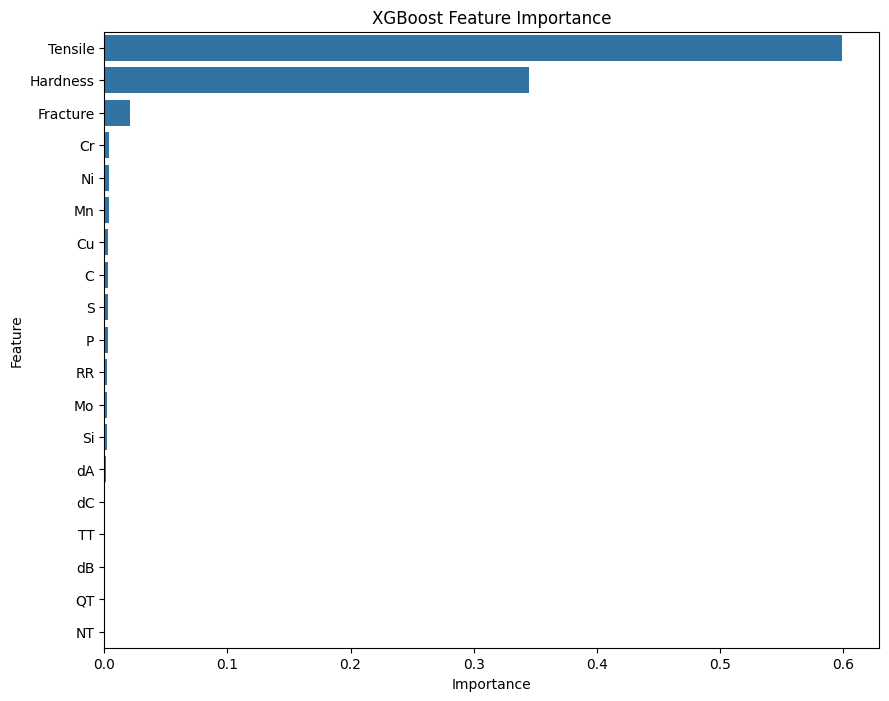

In [120]:
plt.figure(figsize=(10,8))

sns.barplot(

        data=importance,

        x='Importance',

        y='Feature'

)

plt.title("XGBoost Feature Importance")

plt.show()

Step 14: Comparisions of the Models

In [121]:
comparison = pd.DataFrame({

'Model':['Linear Regression',

         'Decision Tree',

         'Random Forest',

         'ANN',

         'XGBoost'],

'MAE':[lr_mae,

       dt_mae,

       rf_mae,

       ann_mae,

       xgb_mae],

'RMSE':[lr_rmse,

        dt_rmse,

        rf_rmse,

        ann_rmse,

        xgb_rmse],

'R2':[lr_r2,

      dt_r2,

      rf_r2,

      ann_r2,

      xgb_r2]

})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,11.743641,15.820251,0.952681
1,Decision Tree,18.457078,23.741726,0.893430
2,Random Forest,12.935963,17.862883,0.939673
3,ANN,19.560032,24.406225,0.887381
4,XGBoost,12.736898,17.266457,0.943634
